# **Laboratorio 1**

---

### Lucía Coudet, Cecilia Waksman

---

# Carga de librerías y verificado de versiones (Python 3.12 y scikit-learn 1.9)

In [1]:
%pip install scikit-learn==1.9.0

In [2]:
import numpy as np
import pandas as pd
import sklearn
import sklearn.preprocessing
import sklearn.feature_selection
pd.options.mode.chained_assignment ='warn' # default='warn'
import graphviz

In [3]:
import sys

print("Python:", sys.version)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
scikit-learn: 1.9.0


# Carga y visualización del dataset

In [4]:
#Leemos los datos
#En https://github.com/schochastics/football-data está el repo original con los datos completos y la documnetación
datos=pd.read_csv('futbol_uruguayo.csv')
datos.head(2)

,home,away,date,gh,ga,full_time,competition,home_ident,away_ident,home_country,away_country,home_code,away_code,home_continent,away_continent,continent,level
0,Bella Vista,Defensor Sporting,1932-03-05,1.0,2.0,F,uruguay,Bella Vista (Uruguay),Defensor Sporting (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national
1,CA Penarol,River Plate,1932-03-05,1.0,1.0,F,uruguay,CA Penarol (Uruguay),River Plate (Uruguay),uruguay,uruguay,UY,UY,South America,South America,South America,national


In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15207 entries, 0 to 15206
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   home            15207 non-null  object 
 1   away            15207 non-null  object 
 2   date            15207 non-null  object 
 3   gh              15207 non-null  float64
 4   ga              15207 non-null  float64
 5   full_time       15207 non-null  object 
 6   competition     15207 non-null  object 
 7   home_ident      15207 non-null  object 
 8   away_ident      15207 non-null  object 
 9   home_country    15207 non-null  object 
 10  away_country    15207 non-null  object 
 11  home_code       15207 non-null  object 
 12  away_code       15207 non-null  object 
 13  home_continent  15207 non-null  object 
 14  away_continent  15207 non-null  object 
 15  continent       15207 non-null  object 
 16  level           15207 non-null  object 
dtypes: float64(2), object(15)
memor

---

# 1. PREPROCESAMIENTO

## - Definimos tipo de los atributos

## - Eliminamos variables que cuentan con 1 solo valor (Uruguay, UY, South America, national) y variables **repetidas**

In [6]:
atributos = pd.DataFrame(datos)
print(atributos.nunique())

home                38
away                38
date              3816
gh                  11
ga                  10
full_time            3
competition          1
home_ident          38
away_ident          38
home_country         1
away_country         1
home_code            1
away_code            1
home_continent       1
away_continent       1
continent            1
level                1
dtype: int64


In [7]:
# Verificamos que solo cuenta con valores enteros
print(datos['gh'].unique())
print(datos['ga'].unique())
print(datos["full_time"].unique()) # El partido terminó: F = en los 90 minutos reglamentarios, E	= en tiempo extra/prórroga, P	= mediante definición por penales

[ 1.  3.  2.  6.  4.  7.  0.  5.  8. 10.  9.]
[2. 1. 0. 3. 4. 5. 6. 7. 8. 9.]
['F' 'P' 'E']


In [8]:
# Verificamos que los atributos identificadores de home y away no agregan información extra, ya que toman los mismos valores
pd.DataFrame({
    'home': datos['home'].unique(),
    'home_ident': datos['home_ident'].unique(),
    'away': datos['away'].unique(),
    'away_ident': datos['away_ident'].unique()
})

,home,home_ident,away,away_ident
0,Bella Vista,Bella Vista (Uruguay),Defensor Sporting,Defensor Sporting (Uruguay)
1,CA Penarol,CA Penarol (Uruguay),River Plate,River Plate (Uruguay)
2,Montevideo Wanderers,Montevideo Wanderers (Uruguay),Racing Club,Racing Club (Uruguay)
3,Central Espanol,Central Espanol (Uruguay),Rampla Juniors Futbol Club,Rampla Juniors Futbol Club (Uruguay)
4,Nacional,Nacional (Uruguay),Institucion Atletica Sud America,Institucion Atletica Sud America (Uruguay)
5,Defensor Sporting,Defensor Sporting (Uruguay),Bella Vista,Bella Vista (Uruguay)
6,Rampla Juniors Futbol Club,Rampla Juniors Futbol Club (Uruguay),Central Espanol,Central Espanol (Uruguay)
7,Racing Club,Racing Club (Uruguay),Nacional,Nacional (Uruguay)
8,River Plate,River Plate (Uruguay),Montevideo Wanderers,Montevideo Wanderers (Uruguay)
9,Institucion Atletica Sud America,Institucion Atletica Sud America (Uruguay),CA Penarol,CA Penarol (Uruguay)


In [9]:
# Categóricos
datos["home"] = datos["home"].astype("category")
datos["away"] = datos["away"].astype("category")
datos["full_time"] =datos["full_time"].astype("category")

# Fechas
datos["date"] = pd.to_datetime(datos["date"])

# Numericos tipo float a enteros
datos["gh"] = datos["gh"].astype(int)
datos["ga"] = datos["ga"].astype(int)

datos = datos.drop(columns=['competition',
                            'home_ident',
                            'away_ident',
                            'home_country',
                            'away_country',
                            'home_code',
                            'away_code',
                            'home_continent',
                            'away_continent',
                            'continent',
                            'level'])

## - Creamos la variable de salida "resultado"



In [10]:
# CREAMOS LA VARIABLE DE SALIDA "RESULTADO"

# Definimos las condiciones
condiciones = [
    datos["gh"] > datos["ga"],  # Gana el local
    datos["gh"] < datos["ga"],  # Gana el visitante
]

# Definimos los resultados para cada condición
opciones = ["L", "V"] # "gana el local", "gana el visitante"

# Aplicamos las condiciones; si no se cumple ninguna (son iguales), asigna "hay empate"
datos["resultado"] = np.select(condiciones, opciones, default="E") # "hay empate"

datos["resultado"] = datos["resultado"].astype("category")

# Ejemplo de visualización
datos[["gh", "ga", "resultado"]].head(2)

,gh,ga,resultado
0,1,2,V
1,1,1,E


## - Eliminamos filas diplicadas
## - Detectamos datos faltantes (no hay)

In [11]:
# ELIMINAMOS FILAS DUPLICADAS
cant_duplicados = datos.duplicated().sum()
print(f"Filas duplicadas encontradas: {cant_duplicados}")
datos = datos.drop_duplicates()

# DETECTAMOS DATOS FALTANTES E IMPUTAMOS MEDIA

print("\nValores faltantes por columna:")
print(datos.isnull().sum())

# Seleccionar columnas numéricas e imputar la media si existen valores nulos

# columnas_numericas = datos.select_dtypes(include=["number"]).columns
# for col in columnas_numericas:
#     if datos[col].isnull().sum() > 0:
#         media_col = datos[col].mean()
#         datos[col] = datos[col].fillna(media_col)
#         print(f"Se imputó la media ({media_col:.2f}) en la columna '{col}'")

Filas duplicadas encontradas: 1

Valores faltantes por columna:
home         0
away         0
date         0
gh           0
ga           0
full_time    0
resultado    0
dtype: int64


## - Creamos nuevos atributos a partir de "date"
## - Eliminamos atributos que tengan información sobre el resultado

In [12]:
# Creamos nuevos atributos para usar en el algoritmo a partir del atributo fecha

# Extraer componentes temporales relevantes:

# Año (para capturar tendencias históricas, ej: evolución del fútbol con las décadas)
datos["year"] = datos["date"].dt.year

# Mes y Trimestre (para capturar estacionalidad en el torneo)
datos["month"] = datos["date"].dt.month

# Día de la semana (0=Lunes, 6=Domingo; útil para ver si se juega fin de semana o entre semana)
datos["dayofweek"] = datos["date"].dt.dayofweek

# Indicador de si es fin de semana (1 si es Sábado/Domingo, 0 si no)
datos["is_weekend"] = datos["dayofweek"].isin([5, 6]).astype(int)

datos = datos.drop(columns=['date', 'gh', 'ga'])

datos.head(2)

,home,away,full_time,resultado,year,month,dayofweek,is_weekend
0,Bella Vista,Defensor Sporting,F,V,1932,3,5,1
1,CA Penarol,River Plate,F,E,1932,3,5,1


In [13]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15206 entries, 0 to 15206
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   home        15206 non-null  category
 1   away        15206 non-null  category
 2   full_time   15206 non-null  category
 3   resultado   15206 non-null  category
 4   year        15206 non-null  int32   
 5   month       15206 non-null  int32   
 6   dayofweek   15206 non-null  int32   
 7   is_weekend  15206 non-null  int64   
dtypes: category(4), int32(3), int64(1)
memory usage: 478.1 KB


---

# 2. MODELOS SUPERVISADOS

Dudas y comentarios:  ⁠
- La partición de los datos que se aplicó toma en cuenta la temporalidad? Tendríamos que implementarlo más explícito con el atributo 'year'?
- Misma partición que se indica en parte 3? 2024 y 2025 para test.
---
- No entendí la diferencia entre la parte 2 y la 3. El tuneo?
- Cuáles serían los modelos "suyos" que dice la letra?
---
- Para el Árbol yo implementaría OneHot y para el CategoricalNB OrdinalEncoder (pasar categorías a enteros)
- Revisar warning en métricas del árbol: no está prediciendo en ningún caso uno de las categorías de respuesta. No implica que esté mal.
- En el foro vi que habría que implementar Features Selection para ver qué atributos usamos. No sé si en ambas partes y si los mismos atributos
- En el NB el "m" no es exactamente lo mismo que "alpha", pero parecido. Supongo que está bien que usemos ese hiperparámetro.
---
- Hay un .ipynb subido donde van las ppt de Metodología para la clasificación. Ahí implementan un pipeline para todo el proceso. Planeo usar eso en la parte 3.

In [14]:
# se particiona los datos en X y Y
datos_y = datos[["resultado"]]
datos_x = datos.drop(["resultado"], axis=1, inplace=False)
#datos_x = datos[["home", "away", "full_time", "year", "month", "dayofweek", "is_weekend"]]

#DIVISION DEL CONJUNTO DE DATOS ENTRENAMIENTO Y PRUEBA
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    datos_x, datos_y, test_size=0.2, random_state=42)

display(X_train.head(5))
display(y_train.head(5))
display(X_train.shape)
display(y_train.shape)

,home,away,full_time,year,month,dayofweek,is_weekend
12093,El Tanque Sisley,Defensor Sporting,F,2014,4,6,1
13404,Montevideo Wanderers,Plaza Colonia,F,2019,5,6,1
6778,Bella Vista,Montevideo Wanderers,F,1990,6,5,1
8478,River Plate,Danubio,F,2000,6,1,0
10251,Club Sportivo Cerrito,Rentistas,F,2006,11,6,1


,resultado
12093,E
13404,E
6778,L
8478,E
10251,E


(12164, 7)

(12164, 1)

In [15]:
display(datos_x.head(5))

,home,away,full_time,year,month,dayofweek,is_weekend
0,Bella Vista,Defensor Sporting,F,1932,3,5,1
1,CA Penarol,River Plate,F,1932,3,5,1
2,Montevideo Wanderers,Racing Club,F,1932,3,5,1
3,Central Espanol,Rampla Juniors Futbol Club,F,1932,3,5,1
4,Nacional,Institucion Atletica Sud America,F,1932,3,5,1


In [16]:
#TRATAMIENTO DE ATRIBUTOS CATEGORICOS

#opcion 1: codificar con valores discretos. Problema: presupone un orden
#opcion 2: one-hot encoding. Problema: aumenta la dimensionalidad de los dato. Optamos por esta.


from sklearn.preprocessing import OneHotEncoder

# Aplicamos One-Hot Encoder aprendiendo solo del conjunto de entrenamiento
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# Ajustar con train y transformar train
X_train_encoded = encoder.fit_transform(X_train[["home", "away", "full_time", "year", "month", "dayofweek", "is_weekend"]])

# Transformar test (sin hacer fit)
X_test_encoded = encoder.transform(X_test[["home", "away", "full_time", "year", "month", "dayofweek", "is_weekend"]])

# ahora convertimos a Y en categorica para ahorrar memoria, aunque no es estrictamente neesario
mapa_resultados = {
    "L": 0,
    "V": 1,
    "E": 2,
}

# Seleccionamos la columna 'resultado'
y_train_encoded = y_train["resultado"].map(mapa_resultados)
y_test_encoded = y_test["resultado"].map(mapa_resultados)

In [17]:
y_test_encoded.head(5)

,resultado
566,0
6712,2
14914,0
6369,1
9380,0


In [18]:
from sklearn.tree import DecisionTreeClassifier

modelo = DecisionTreeClassifier(random_state=42)
modelo.fit(X_train_encoded, y_train_encoded)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [19]:
# ==============================================================================
# IMPLEMENTACIÓN DEL ÁRBOL DE DECISIÓN CON GANANCIA MÍNIMA DE INFORMACIÓN
# ==============================================================================

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# Defina el valor de la ganancia mínima de información deseada
min_info_gain = 0.01

# Inicializar el Árbol de Decisión:
# - criterion='entropy': calcula la Ganancia de Información (Information Gain)
# - min_impurity_decrease=min_info_gain: detiene la división cuando la ganancia es menor al valor especificado
arbol_modelo = DecisionTreeClassifier(
    criterion="entropy", min_impurity_decrease=min_info_gain, random_state=42
)

# Entrenar el modelo
arbol_modelo.fit(X_train_encoded, y_train_encoded)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.01
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively in

In [20]:

# ==============================================================================
# EVALUACIÓN DEL MODELO SOBRE EL CONJUNTO DE PRUEBA
# ==============================================================================
y_pred = arbol_modelo.predict(X_test_encoded)

print(
    f"=== Árbol de Decisión (min_info_gain = {min_info_gain}) ==="
)
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred))


=== Árbol de Decisión (min_info_gain = 0.01) ===
Exactitud (Accuracy): 0.4875

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.48      0.94      0.63      1332
           1       0.54      0.27      0.36       862
           2       0.00      0.00      0.00       848

    accuracy                           0.49      3042
   macro avg       0.34      0.40      0.33      3042
weighted avg       0.36      0.49      0.38      3042



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


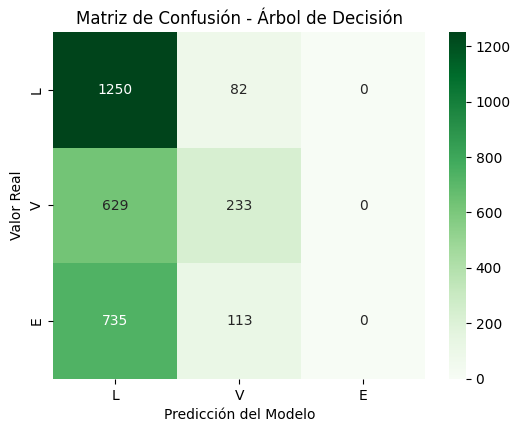

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generar la matriz usando y_test_encoded y los índices numéricos [0, 1, 2]
cm = confusion_matrix(y_test_encoded, y_pred, labels=[0, 1, 2])

# 2. Si definiste un LabelEncoder llamado 'le', podemos obtener el orden exacto de las clases:
# etiquetas_visibles = le.classes_  # Ejemplo: ['E', 'L', 'V']
# O si prefieres forzar el texto fijo en ese orden:
etiquetas_visibles = ["L", "V", "E"]

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=etiquetas_visibles,
    yticklabels=etiquetas_visibles,
)
plt.title("Matriz de Confusión - Árbol de Decisión")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

=== Naive Bayes (m = 1.0) ===
Exactitud (Accuracy): 0.4750

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.53      0.68      0.60      1332
           1       0.43      0.51      0.47       862
           2       0.31      0.11      0.17       848

    accuracy                           0.48      3042
   macro avg       0.42      0.43      0.41      3042
weighted avg       0.44      0.48      0.44      3042



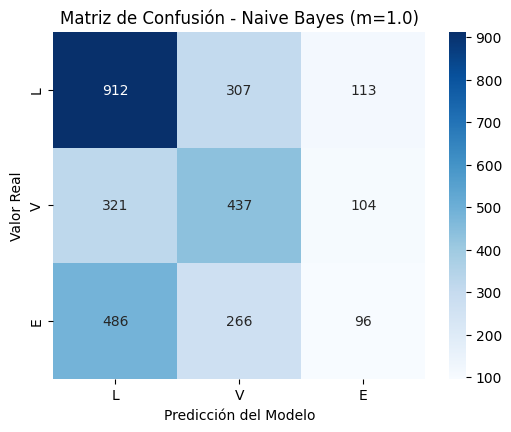

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

# ==============================================================================
# IMPLEMENTACIÓN DE NAIVE BAYES (m-estimate)
# ==============================================================================

# 1. Definir el hiperparámetro m (tamaño equivalente de muestra)
m_param = 1.0

# Para CategoricalNB, alpha corresponde al suavizado de Laplace.
# Si consideramos p uniforme, ajustamos alpha = m_param
nb_modelo = CategoricalNB(alpha=m_param)

# 2. Entrenar el modelo
# Nota: CategoricalNB requiere datos de entrada categóricos discretos/codificados
nb_modelo.fit(X_train_encoded, y_train_encoded)

# 3. Predicción
y_pred_nb = nb_modelo.predict(X_test_encoded)

# ==============================================================================
# EVALUACIÓN DEL MODELO
# ==============================================================================
print(f"=== Naive Bayes (m = {m_param}) ===")
print(f"Exactitud (Accuracy): {accuracy_score(y_test_encoded, y_pred_nb):.4f}\n")

print("Reporte de Clasificación:")
print(classification_report(y_test_encoded, y_pred_nb))

# Matriz de Confusión
cm_nb = confusion_matrix(y_test_encoded, y_pred_nb, labels=[0, 1, 2])

plt.figure(figsize=(6, 4.5))
sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["L", "V", "E"],
    yticklabels=["L", "V", "E"],
)
plt.title(f"Matriz de Confusión - Naive Bayes (m={m_param})")
plt.xlabel("Predicción del Modelo")
plt.ylabel("Valor Real")
plt.show()

In [23]:
#IMPLEMENTACION DEL CLASIFICADOR BASE

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin


class Historico10AniosClassifier(BaseEstimator, ClassifierMixin):

    def __init__(self):
        self.win_ratios = {}
        self.clase_mayoritaria = 0

    def fit(self, X, y):
        # 1. Determinar la clase mayoritaria global
        uniques, counts = np.unique(y, return_counts=True)
        self.clase_mayoritaria = uniques[np.argmax(counts)]

        # 2. Reconstruir DataFrame auxiliar con las características necesarias
        df = X.copy()
        df["ganador"] = y

        # 3. Filtrar los últimos 10 años presentes en Train
        max_year = df["year"].max()
        df_10y = df[df["year"] >= (max_year - 10)]

        # 4. Calcular partidos jugados y ganados por equipo
        equipos = set(df_10y["home"]).union(set(df_10y["away"]))
        stats = {
            eq: {"jugados": 0, "ganados": 0} for eq in equipos if pd.notna(eq)
        }

        for _, row in df_10y.iterrows():
            h, a, res = row["home"], row["away"], row["ganador"]

            if h in stats:
                stats[h]["jugados"] += 1
                # Si el equipo local ganó (res puede ser 'L' o su versión codificada 0/1/2)
                if res in ["L", 0]:
                    stats[h]["ganados"] += 1

            if a in stats:
                stats[a]["jugados"] += 1
                # Si el equipo visitante ganó
                if res in ["V", 1]:
                    stats[a]["ganados"] += 1

        # 5. Calcular la proporción de victorias por equipo
        for eq, dat in stats.items():
            self.win_ratios[eq] = (
                dat["ganados"] / dat["jugados"] if dat["jugados"] > 0 else 0.0
            )

        return self

    def predict(self, X):
        predictions = []
        for _, row in X.iterrows():
            h_ratio = self.win_ratios.get(row["home"], 0.0)
            a_ratio = self.win_ratios.get(row["away"], 0.0)

            # Si el local tiene mayor proporción de victorias -> Predice 'L' (o 0)
            if h_ratio > a_ratio:
                predictions.append(0)
            # Si el visitante tiene mayor proporción -> Predice 'V' (o 1)
            elif a_ratio > h_ratio:
                predictions.append(1)
            # Empate técnico de historial -> Predice la clase mayoritaria del dataset
            else:
                predictions.append(self.clase_mayoritaria)

        return np.array(predictions)

Modelo: Clasificador Base (Histórico 10 años)
Accuracy: 0.4583

              precision    recall  f1-score   support

           0       0.54      0.63      0.58      1332
           1       0.37      0.65      0.47       862
           2       0.00      0.00      0.00       848

    accuracy                           0.46      3042
   macro avg       0.31      0.43      0.35      3042
weighted avg       0.34      0.46      0.39      3042



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Modelo: Árbol de Decisión (entropy)
Accuracy: 0.4875

              precision    recall  f1-score   support

           0       0.48      0.94      0.63      1332
           1       0.54      0.27      0.36       862
           2       0.00      0.00      0.00       848

    accuracy                           0.49      3042
   macro avg       0.34      0.40      0.33      3042
weighted avg       0.36      0.49      0.38      3042



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Modelo: Naive Bayes (CategoricalNB)
Accuracy: 0.4750

              precision    recall  f1-score   support

           0       0.53      0.68      0.60      1332
           1       0.43      0.51      0.47       862
           2       0.31      0.11      0.17       848

    accuracy                           0.48      3042
   macro avg       0.42      0.43      0.41      3042
weighted avg       0.44      0.48      0.44      3042

Modelo: Random Forest
Accuracy: 0.4855

              precision    recall  f1-score   support

           0       0.54      0.69      0.60      1332
           1       0.50      0.47      0.48       862
           2       0.30      0.18      0.22       848

    accuracy                           0.49      3042
   macro avg       0.44      0.45      0.44      3042
weighted avg       0.46      0.49      0.46      3042



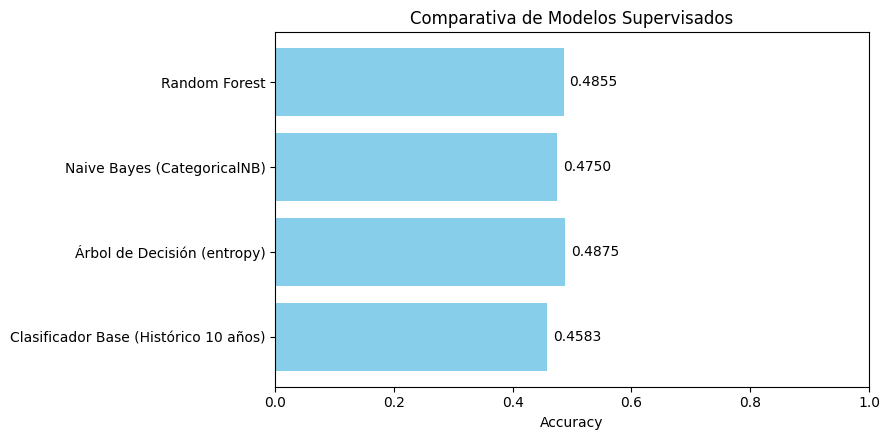

In [24]:
# IMPLEMENTACION Y COMPARATIVA DE TODOS LOS MODELOS IMPLEMENTADOS

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier

# Diccionario para almacenar los modelos
modelos = {
    "Clasificador Base (Histórico 10 años)": Historico10AniosClassifier(),
    "Árbol de Decisión (entropy)": DecisionTreeClassifier(
        criterion="entropy", min_impurity_decrease=0.01, random_state=42
    ),
    "Naive Bayes (CategoricalNB)": CategoricalNB(alpha=1.0),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
}

resultados = {}

# Entrenar y evaluar cada modelo
for nombre, model in modelos.items():
    if nombre == "Clasificador Base (Histórico 10 años)":
        # El clasificador base necesita las columnas 'home', 'away' y 'year' sin codificar
        model.fit(X_train, y_train_encoded)
        y_pred = model.predict(X_test)
    else:
        # Los modelos de scikit-learn consumen las matrices codificadas OHE
        model.fit(X_train_encoded, y_train_encoded)
        y_pred = model.predict(X_test_encoded)

    acc = accuracy_score(y_test_encoded, y_pred)
    resultados[nombre] = acc

    print(f"==================================================")
    print(f"Modelo: {nombre}")
    print(f"Accuracy: {acc:.4f}\n")
    print(classification_report(y_test_encoded, y_pred))

# Visualización comparativa de Accuracy
plt.figure(figsize=(9, 4.5))
bars = plt.barh(list(resultados.keys()), list(resultados.values()), color="skyblue")
plt.xlim(0, 1)
plt.xlabel("Accuracy")
plt.title("Comparativa de Modelos Supervisados")

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.4f}",
        va="center",
    )

plt.tight_layout()
plt.show()

# 3. EXPERIMENTACIÓN

- Si modelo base ya está en parte 2, no se agrega, no? Quizás imprimir de nuevo matriz de confusión y/o métricas
- Tunear mejor hiperparámetros
- Agregar hiperparámetros a NB?
- Falta features selection
- Falta graficar error según valores de cada hiperparámetro
- PAra resultados de test faltan: todas las otras métricas (precisión, recall, F1 por clase y macro-F1) y matrices de confusión

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import CategoricalNB
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Listas a las columnas del dataset que usaremos como predictoras
numeric_features = [ 'year', 'month', 'dayofweek', 'is_weekend']
categorical_features = ['home', 'away', 'full_time']

all_features = numeric_features + categorical_features

# Pipeline para los atributos categóricos
pipeline_arbol = Pipeline([
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

# Aplicamos un pipeline diferente a cada grupo de columnas
preprocessing_arbol = ColumnTransformer([
    ('numeric', 'passthrough', numeric_features),
    ('categorical', pipeline_arbol, categorical_features)
])

preprocessing_nb = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# Pipeline inicial, luego se sobreescribe con los modelos definidos en param_grid
pipeline = Pipeline([
    ('preprocessing', 'passthrough'),
    ('model', 'passthrough')
])

# Hiperparámetros del preprocesamiento y del modelo
param_grid = [

    #### Arbol
    {
        'preprocessing': [preprocessing_arbol],
        'model': [DecisionTreeClassifier(random_state=42)],

        # Preprocesamiento categórico
        'preprocessing__categorical__onehot__drop': [
            None,
            'first'
        ],
        # min_impurity_decrease es min_info_gain
        'model__min_impurity_decrease': [
            0.0,
            0.005,
            0.01,
            0.05
        ],
        'model__max_depth': [
            3,
            5,
            None
        ],
        'model__min_samples_leaf': [
            1,
            10,
            50,
            200
        ]
    },

    ##### NB
    {
        'preprocessing': [preprocessing_nb],
        'model': [CategoricalNB()],

        # alpha es análogo a m
        'model__alpha': [
            0.01, 0.1, 0.5, 1, 2, 5, 10
        ]
    }
]


Mejores hiperparámetros:
{'model': CategoricalNB(), 'model__alpha': 10, 'preprocessing': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}

Mejor accuracy medio: 0.497
Accuracy en test: 0.479


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Estrategia de cross-validation
cv = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)


grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1,
    refit=True
)


# # GridSearchCV realiza internamente la validación cruzada
# grid_search.fit(X_train, y_train)


# print("Mejores hiperparámetros:")
# print(grid_search.best_params_)

# print(f"\nMejor accuracy medio: {grid_search.best_score_:.3f}")


# # Evaluación final sobre test
# test_accuracy = grid_search.score(X_test, y_test)
# print(f"Accuracy en test: {test_accuracy:.3f}")

In [32]:
resultados = pd.DataFrame(grid_search.cv_results_)

# Identificar modelo
resultados['modelo'] = resultados['param_model'].apply(
    lambda x: type(x).__name__
)


# Mejor árbol
mejor_arbol = (
    resultados[
        resultados['modelo'] == 'DecisionTreeClassifier'
    ]
    .sort_values('mean_test_score', ascending=False)
    .iloc[0]
)

print("=== MEJOR ÁRBOL ===")
print(
    f"Accuracy medio CV: "
    f"{mejor_arbol['mean_test_score']:.3f}"
)
print("Hiperparámetros:")
print(mejor_arbol['params'])



# Mejor Naive Bayes
mejor_nb = (
    resultados[
        resultados['modelo'] == 'CategoricalNB'
    ]
    .sort_values('mean_test_score', ascending=False)
    .iloc[0]
)

print("\n=== MEJOR CATEGORICAL NB ===")
print(
    f"Accuracy medio CV: "
    f"{mejor_nb['mean_test_score']:.3f}"
)
print("Hiperparámetros:")
print(mejor_nb['params'])

=== MEJOR ÁRBOL ===
Accuracy medio CV: 0.495
Hiperparámetros:
{'model': DecisionTreeClassifier(random_state=42), 'model__max_depth': None, 'model__min_impurity_decrease': 0.0, 'model__min_samples_leaf': 50, 'preprocessing': ColumnTransformer(transformers=[('numeric', 'passthrough',
                                 ['year', 'month', 'dayofweek', 'is_weekend']),
                                ('categorical',
                                 Pipeline(steps=[('onehot',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['home', 'away', 'full_time'])]), 'preprocessing__categorical__onehot__drop': 'first'}

=== MEJOR CATEGORICAL NB ===
Accuracy medio CV: 0.497
Hiperparámetros:
{'model': CategoricalNB(), 'model__alpha': 10, 'preprocessing': OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)}


In [33]:

# Reentrenar mejores modelos


from sklearn.base import clone

mejor_pipeline_arbol = clone(pipeline)
mejor_pipeline_arbol.set_params(**mejor_arbol['params'])
mejor_pipeline_arbol.fit(X_train, y_train)

mejor_pipeline_nb = clone(pipeline)
mejor_pipeline_nb.set_params(**mejor_nb['params'])
mejor_pipeline_nb.fit(X_train, y_train)



# Evaluación sobre test


y_pred_arbol = mejor_pipeline_arbol.predict(X_test)
y_pred_nb = mejor_pipeline_nb.predict(X_test)

print(
    "\nAccuracy test Árbol:",
    accuracy_score(y_test, y_pred_arbol)
)

print(
    "Accuracy test CategoricalNB:",
    accuracy_score(y_test, y_pred_nb)
)


Accuracy test Árbol: 0.4986850756081525
Accuracy test CategoricalNB: 0.47928994082840237


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
